<a href="https://colab.research.google.com/github/goktuggokmen/Graduation-Thesis-Automated-Fish-Species-Recognition-via-ResNet-50-Architecture/blob/main/Fish%20Recognition%20using%20ResNet-50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import random
import os
from glob import glob

from shutil import copyfile, rmtree
from pathlib import Path

import itertools
import warnings
warnings.filterwarnings("ignore")

In [ ]:
INPUT_CLASSES_DIR = '/content/drive/MyDrive/Species/Training_Set'

# train/test ornekleme boyutlari
TRAIN_SAMPLE_SIZE = 1000
TEST_SAMPLE_SIZE = 200

In [ ]:
# veri setindeki mevcut tum turlerin listesi
files = glob(INPUT_CLASSES_DIR + '/*')

print([x.split('/')[-1] for x in files])

['Atherinomorus lacunosus', 'Anthias anthias', 'Polyprion americanus', 'Belone belone', 'Boops boops', 'Chlorophthalmus agassizi', 'Coris julis', 'Dasyatis centroura', 'Epinephelus caninus', 'Gobius niger', 'Mugil cephalus', 'Phycis phycis', 'Pseudocaranx dentex', 'Rhinobatos cemiculus', 'Scomber japonicus', 'Solea solea', 'Squalus acanthias', 'Tetrapturus belone', 'Trachinus draco', 'Trigloporus lastoviza']


In [ ]:
train = './train'
test = './test'

In [ ]:
# ornekleri olusturur ve dosyalari train/test dosyalarina kopyalar

#rmtree dosyanin icerigini temizler.
rmtree(train, ignore_errors=True)
rmtree(test, ignore_errors=True)

for dirname in files:
    if len(os.listdir(dirname)) < TRAIN_SAMPLE_SIZE + TEST_SAMPLE_SIZE:
        print(f'{dirname} contains less files than needed')
        break
    else:
        # her alt klasordeki dosyalarin ornek listesi
        current_subfolder = dirname.split('/')[-1]
        folder_sample = random.sample(glob(dirname + '/*'), TRAIN_SAMPLE_SIZE + TEST_SAMPLE_SIZE)
        Path(f"{test}/{current_subfolder}").mkdir(parents=True, exist_ok=True) #test dizini olusturur
        Path(f"{train}/{current_subfolder}").mkdir(parents=True, exist_ok=True) #train dizini olusturur
        train_filenames = folder_sample[:TRAIN_SAMPLE_SIZE]
        for f in train_filenames:
            copyfile(f, f"{train}/{current_subfolder}/{f.split('/')[-1]}")
        test_filenames = folder_sample[TRAIN_SAMPLE_SIZE:]
        for f in test_filenames:
            copyfile(f, f"{test}/{current_subfolder}/{f.split('/')[-1]}")

In [ ]:
# dosya sayisi
train_files = glob(train + '/*/*.jp*g')
test_files = glob(test + '/*/*.jp*g')
print(len(train_files))
print(len(test_files))

20000
4000


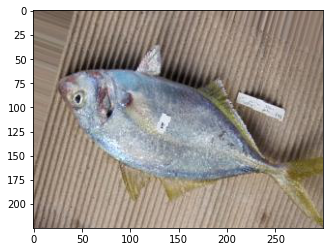

In [ ]:
# train verisinden rastgele bir gorsel
plt.imshow(image.load_img(np.random.choice(train_files)))

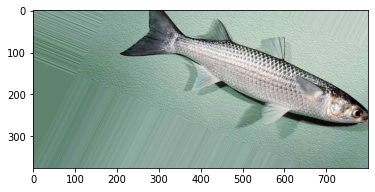

In [ ]:
# test verisinden rastgele bir gorsel
plt.imshow(image.load_img(np.random.choice(test_files)))

In [ ]:
IMAGE_SIZE = [200, 200]

# train config:
epochs = 20
batch_size = 128

In [ ]:
# resnet
resnet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# mevcut agirliklari egitme
for layer in resnet.layers:
  layer.trainable = False

# bizim ekleyecegimiz katman
x = Flatten()(resnet.output) # matris formundaki cikisi duzlestirmek icin kullanilir
prediction = Dense(len(files), activation='softmax')(x)

94781440/94765736 [==============================] - 1s 0us/step


In [ ]:
# modeli olusturma
model = Model(inputs=resnet.input, outputs=prediction)

# modeli derleme
model.compile(
loss='sparse_categorical_crossentropy',
optimizer='adam',
metrics=['accuracy'])

In [ ]:
# modelin yapisi
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 200, 200, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 206, 206, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 100, 100, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [ ]:
# ImageDataGenerator
train_gen = ImageDataGenerator(
  rotation_range=20,
  width_shift_range=0.1,
  height_shift_range=0.1,
  shear_range=0.1,
  zoom_range=0.2,
  horizontal_flip=True,
  vertical_flip=True,
  preprocessing_function=preprocess_input
)

val_gen = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

In [ ]:
# karisiklik matrisi tablosu icin etiketler alinir
test_gen = val_gen.flow_from_directory(test, target_size=IMAGE_SIZE)
print(test_gen.class_indices)
labels = [None] * len(test_gen.class_indices)
for k, v in test_gen.class_indices.items():
  labels[v] = k

Found 4000 images belonging to 20 classes.
{'Anthias anthias': 0, 'Atherinomorus lacunosus': 1, 'Belone belone': 2, 'Boops boops': 3, 'Chlorophthalmus agassizi': 4, 'Coris julis': 5, 'Dasyatis centroura': 6, 'Epinephelus caninus': 7, 'Gobius niger': 8, 'Mugil cephalus': 9, 'Phycis phycis': 10, 'Polyprion americanus': 11, 'Pseudocaranx dentex': 12, 'Rhinobatos cemiculus': 13, 'Scomber japonicus': 14, 'Solea solea': 15, 'Squalus acanthias': 16, 'Tetrapturus belone': 17, 'Trachinus draco': 18, 'Trigloporus lastoviza': 19}


In [ ]:
# create generators
train_generator = train_gen.flow_from_directory( #train goruntuleri okunur
  train,
  target_size=IMAGE_SIZE,
  shuffle=True,
  batch_size=batch_size,
  class_mode='sparse',
)
valid_generator = val_gen.flow_from_directory( #validation goruntuleri okunur
  test,
  target_size=IMAGE_SIZE,
  shuffle=False,
  batch_size=batch_size,
  class_mode='sparse',
)

Found 20000 images belonging to 20 classes.
Found 4000 images belonging to 20 classes.


In [ ]:
# model egitim veri setiyle egitilir
r = model.fit(
  train_generator,
  validation_data = valid_generator,
  epochs=epochs,
  steps_per_epoch = len(train_files) // batch_size, #tur (epoch) basina adim (step)
  validation_steps = len(test_files) // batch_size,
)

Epoch 1/20
156/156 [==============================] - 311s 2s/step - loss: 4.4769 - accuracy: 0.7353 - val_loss: 1.8866 - val_accuracy: 0.8722
Epoch 2/20
156/156 [==============================] - 289s 2s/step - loss: 1.9065 - accuracy: 0.8747 - val_loss: 1.5188 - val_accuracy: 0.9047
Epoch 3/20
156/156 [==============================] - 289s 2s/step - loss: 1.6715 - accuracy: 0.9016 - val_loss: 1.3763 - val_accuracy: 0.9246
Epoch 4/20
156/156 [==============================] - 288s 2s/step - loss: 1.5680 - accuracy: 0.9134 - val_loss: 1.2640 - val_accuracy: 0.9340
Epoch 5/20
156/156 [==============================] - 287s 2s/step - loss: 1.2972 - accuracy: 0.9285 - val_loss: 1.3338 - val_accuracy: 0.9395
Epoch 6/20
156/156 [==============================] - 287s 2s/step - loss: 1.3068 - accuracy: 0.9319 - val_loss: 1.1126 - val_accuracy: 0.9501
Epoch 7/20
156/156 [==============================] - 287s 2s/step - loss: 1.2834 - accuracy: 0.9380 - val_loss: 1.1835 - val_accuracy: 0.9448

In [ ]:
#olusturulan modeli kaydetme
model.save('fish.h5')

In [ ]:
# from keras.models import load_model
# yuklemek icin
# model = load_model('model_trained.h5')

In [ ]:
#r.history

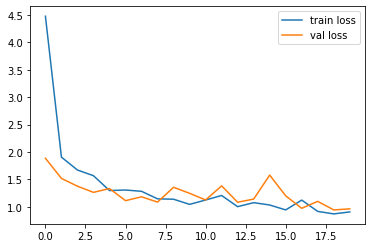

In [ ]:
# loss grafikleri
plt.plot(r.history['loss'], label='train loss')
if 'val_loss' in r.history:
    plt.plot(r.history['val_loss'], label='val loss')
plt.legend();

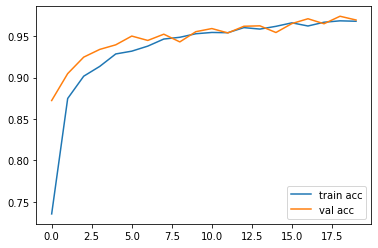

In [ ]:
# accuracy grafikleri
plt.plot(r.history['accuracy'], label='train acc')
if 'val_accuracy' in r.history:
    plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend();

In [ ]:
def get_confusion_matrix(data, N):
  print("Generating confusion matrix", N)
  predictions = []
  targets = []
  i = 0
  n_images = 0
  for x, y in val_gen.flow_from_directory(
      data,
      target_size=IMAGE_SIZE,
      shuffle=False,
      batch_size=batch_size * 2):
    i += 1
    n_images += len(y)
    if i % 50 == 0:
      print(f'{n_images} images processed.')
    p = model.predict(x)
    p = np.argmax(p, axis=1)
    y = np.argmax(y, axis=1)
    predictions = np.concatenate((predictions, p))
    targets = np.concatenate((targets, y))
    if len(targets) >= N:
      break

  cm = confusion_matrix(targets, predictions)
  return cm

In [ ]:
cm = get_confusion_matrix(train, len(train_files))
print(cm)
test_cm = get_confusion_matrix(test, len(test_files))
print(test_cm)

Generating confusion matrix 20000
Found 20000 images belonging to 20 classes.
12800 images processed.
[[1000    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   1  986    0    1    2    0    0    0    0    2    1    1    1    0
     2    0    0    0    3    0]
 [   0    1  990    0    1    0    0    0    0    0    1    0    0    0
     3    0    3    0    1    0]
 [   1    6    1  962    1    3    0    0    0    3    2    4    4    0
     7    0    3    0    2    1]
 [   0    2    0    0  998    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0    0 1000    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0    0    0  991    1    0    0    0    3    0    2
     0    0    2    1    0    0]
 [   0    0    0    0    0    0    0  956    1    0    7   30    1    0
     0    2    1    0    2    0]
 [   0    1    0    0    1    0    0    0  985    0    1  

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
  """
  This function prints and plots the confusion matrix.
  Normalization can be applied by setting `normalize=True`.
  """
  if normalize:
      cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
      print("Normalized confusion matrix")
  else:
      print('Confusion matrix, without normalization')

  print(cm)

  plt.figure(figsize=(30, 30))
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt),
               horizontalalignment="center",
               color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()

Confusion matrix, without normalization
[[1000    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   1  986    0    1    2    0    0    0    0    2    1    1    1    0
     2    0    0    0    3    0]
 [   0    1  990    0    1    0    0    0    0    0    1    0    0    0
     3    0    3    0    1    0]
 [   1    6    1  962    1    3    0    0    0    3    2    4    4    0
     7    0    3    0    2    1]
 [   0    2    0    0  998    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0    0 1000    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0    0    0  991    1    0    0    0    3    0    2
     0    0    2    1    0    0]
 [   0    0    0    0    0    0    0  956    1    0    7   30    1    0
     0    2    1    0    2    0]
 [   0    1    0    0    1    0    0    0  985    0    1    3    0    2
     0    0    0    0    6    1]
 [   0    3    

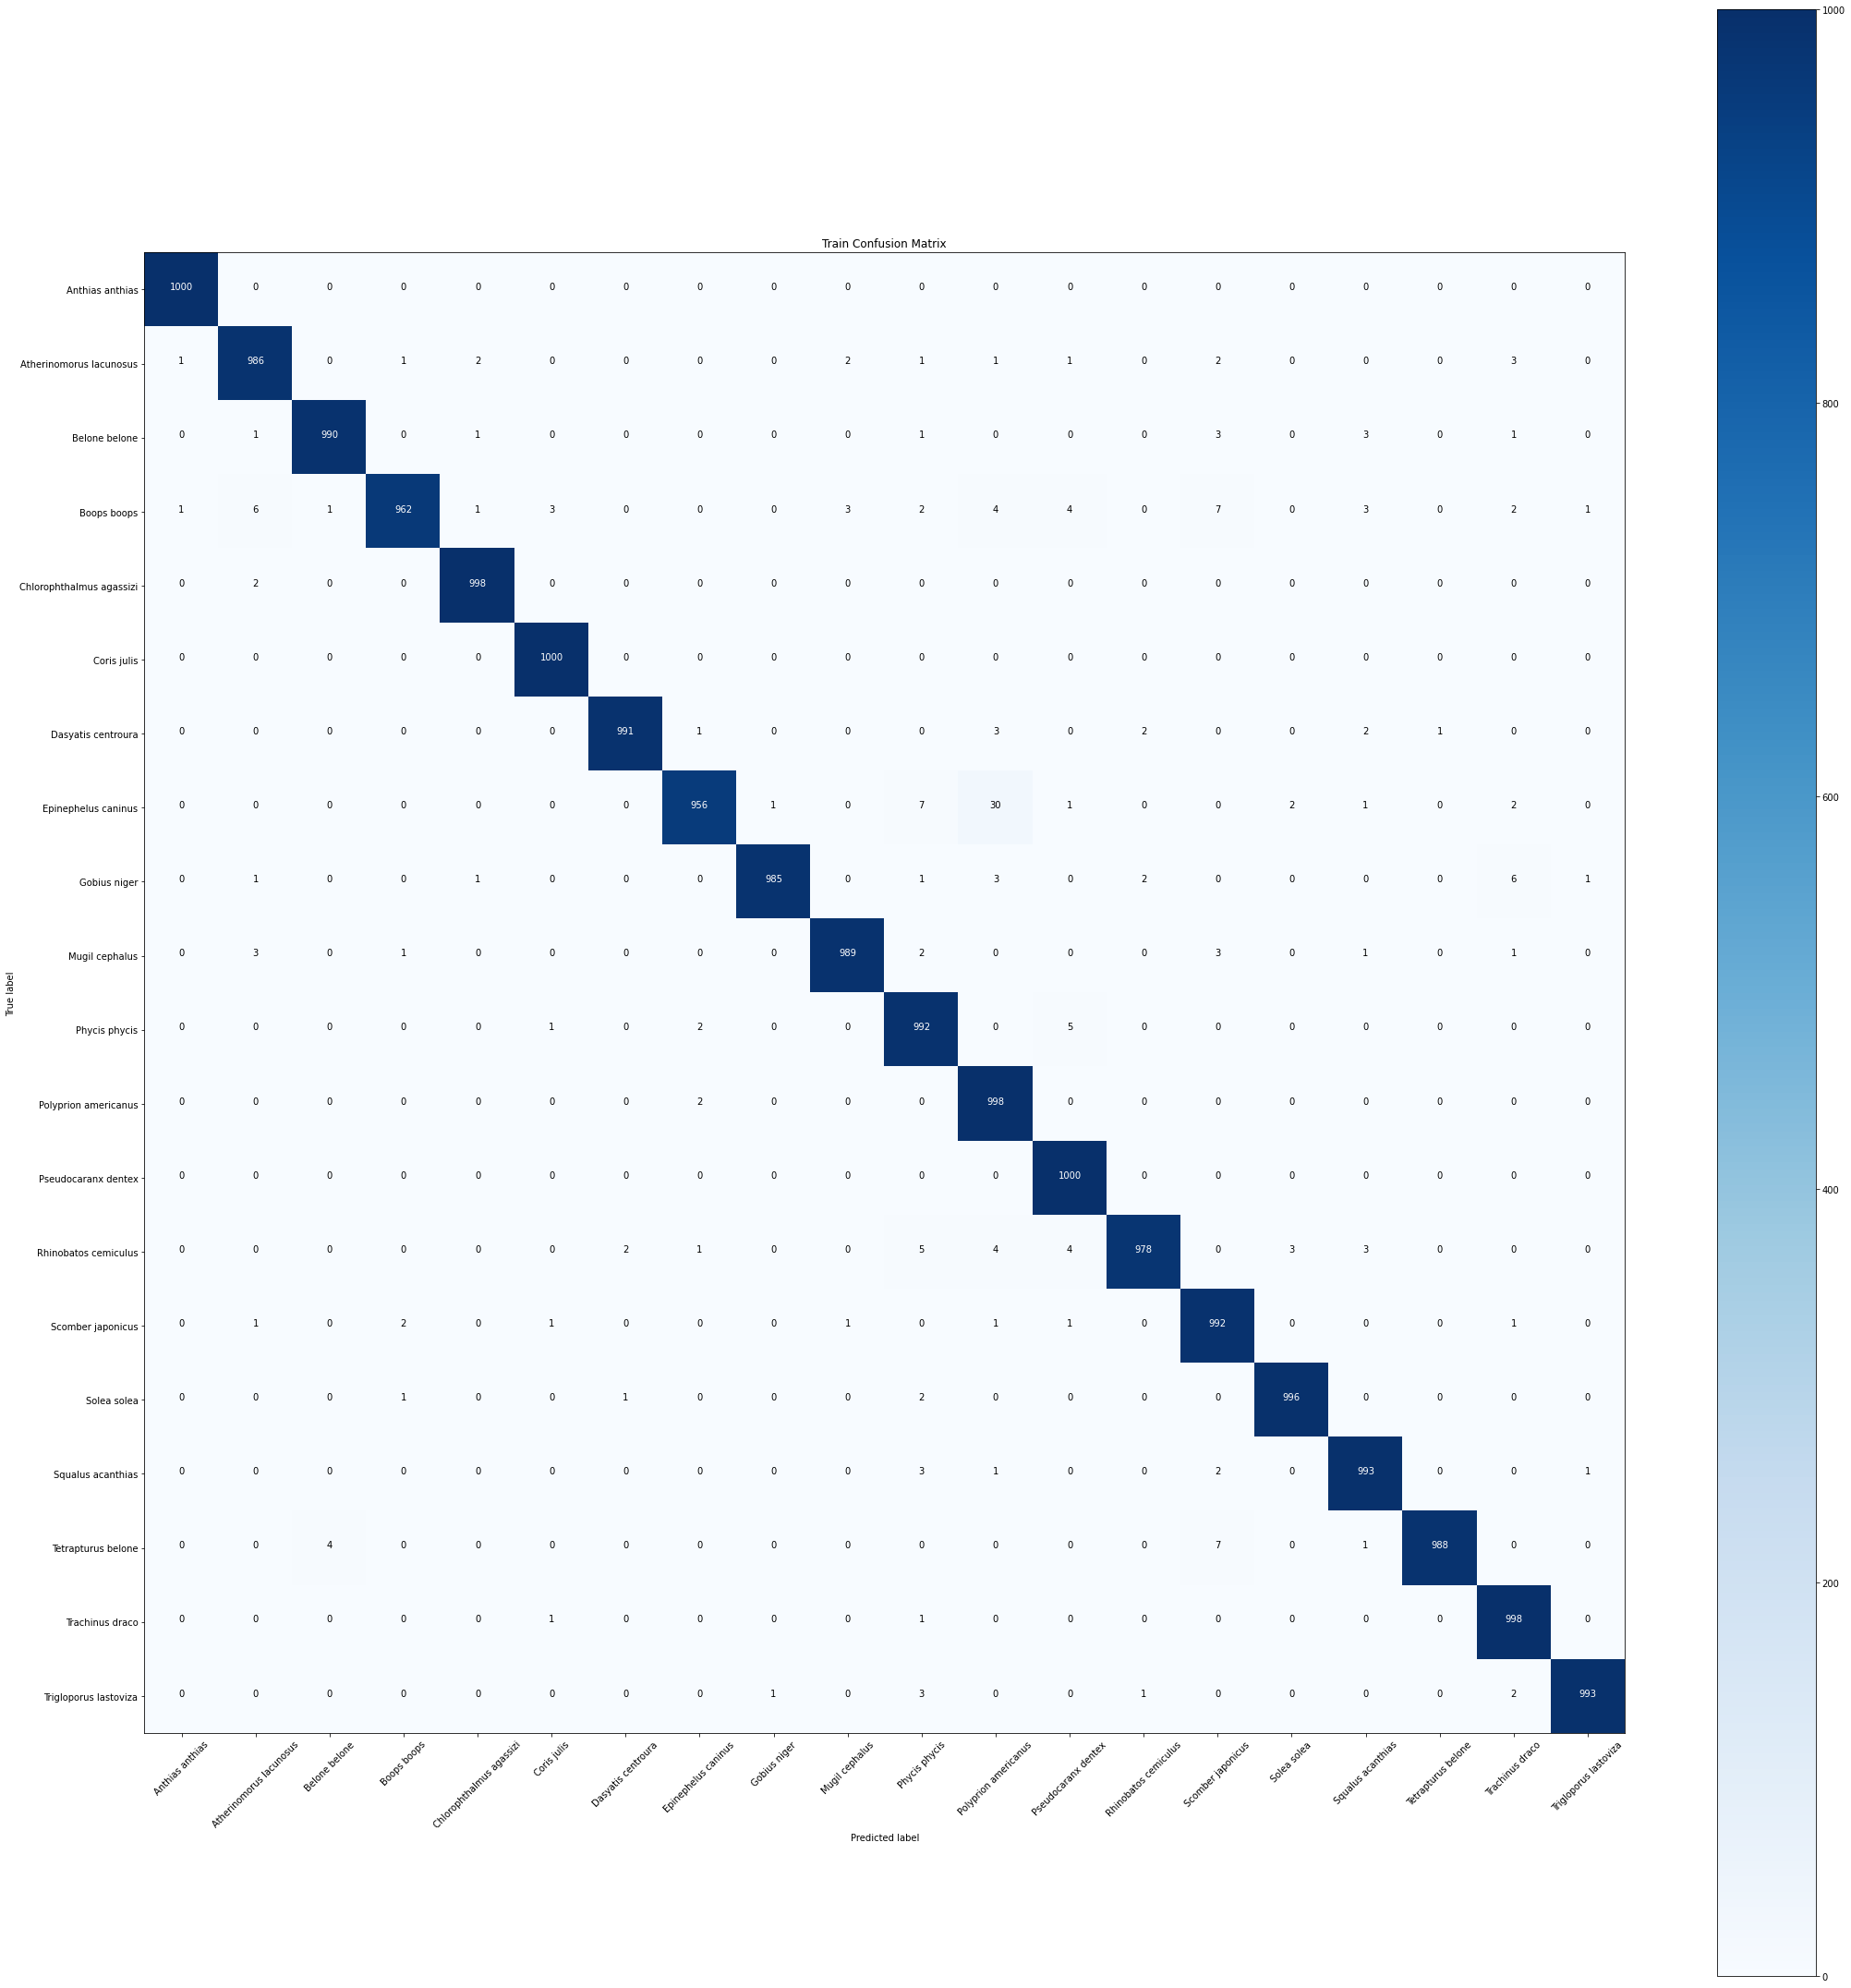

In [ ]:
plot_confusion_matrix(cm, labels, title='Train Confusion Matrix')

Confusion matrix, without normalization
[[200   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 186   1   1   2   0   0   0   0   2   2   0   0   0   6   0   0   0
    0   0]
 [  0   1 193   0   1   1   0   0   0   0   2   0   0   0   2   0   0   0
    0   0]
 [  0   6   0 181   0   0   0   0   0   1   2   1   7   0   2   0   0   0
    0   0]
 [  0   1   0   0 198   0   0   1   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   1   0 196   0   0   0   0   0   0   0   0   1   0   1   0
    1   0]
 [  0   0   0   0   0   0 196   0   0   0   0   1   0   0   0   1   2   0
    0   0]
 [  0   0   0   0   0   0   0 181   0   0   2  13   3   0   0   0   1   0
    0   0]
 [  0   2   1   0   0   0   0   2 187   0   0   3   0   1   0   0   0   0
    3   1]
 [  0   0   0   4   0   0   0   0   0 188   1   0   0   0   0   0   1   0
    5   1]
 [  0   0   0   0   0   0   0   3   0   0 194   1   1   0   0   0   1   0
    0   0]
 [  0   0   0   0   0   0

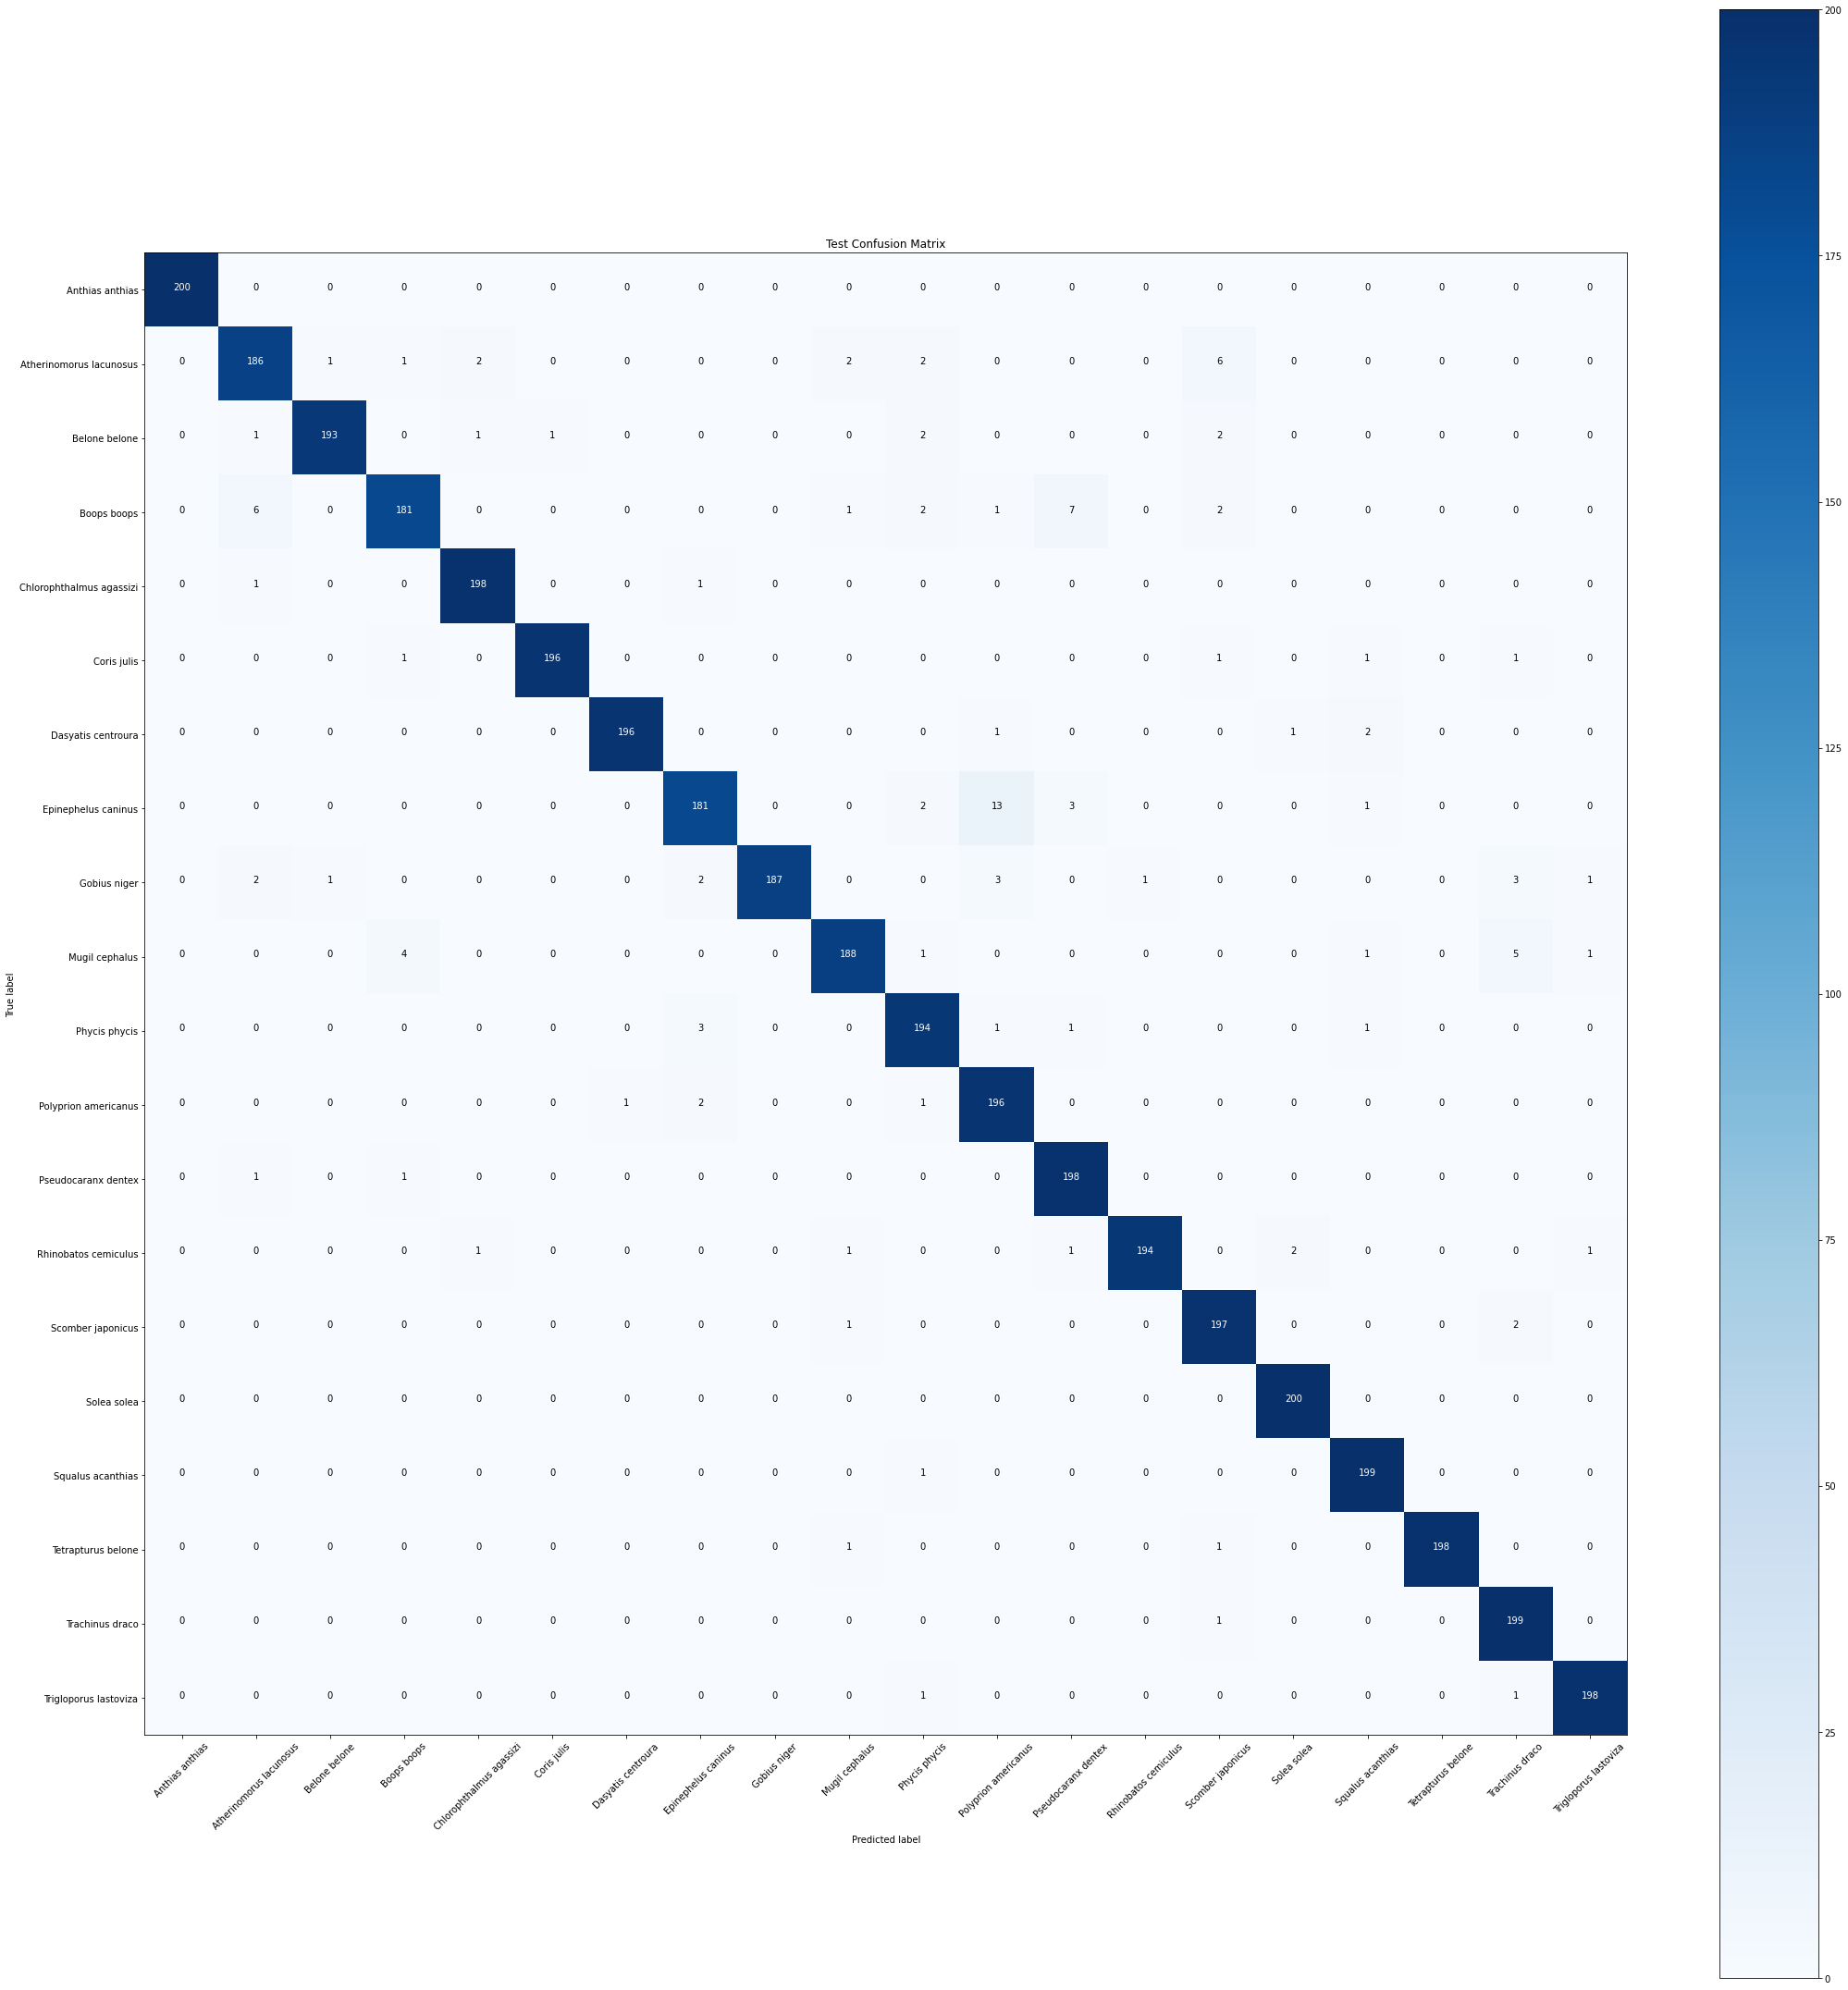

In [ ]:
plot_confusion_matrix(test_cm, labels, title='Test Confusion Matrix')